# ECG Guard — Uncertainty, Noise Robustness & Human-Review Triage

## Patient-disjoint ECG modelling with calibration, abstention and signal-quality controls

This edition preserves the full existing ECG experiment and surfaces its strongest engineering evidence: real MIT-BIH waveforms, patient-disjoint splits, a signal-feature baseline, a 1D CNN, validation-only calibration, clustered uncertainty analysis, corruption stress testing and a human-review routing policy.


## Held-out evidence summary

| Measure | Result |
|---|---:|
| Test beats | **3,600** |
| Test subject groups | **9** |
| Positive S/V fraction | **9.17%** |
| CNN ROC-AUC | **0.8993** |
| CNN PR-AUC | **0.558** |
| Logistic baseline PR-AUC | **0.532** |
| CNN S/V recall | **84.85%** |
| Calibrated Brier score | **0.1403** |
| Validation-selected coverage on test | **71.53%** |
| Retained test error | **13.59%** |
| S/V recall among retained beats | **91.67%** |
| CNN PR-AUC at 0.20 mV white noise | **0.386** |
| Worst observed subject-group error | **81.0%** |

The patient-cluster bootstrap interval for the CNN-minus-logistic PR-AUC difference spans **-0.394 to +0.364**, so superiority of the CNN is not established. That uncertainty is intentionally retained rather than hidden.


In [26]:
ecg_decision_scorecard = pd.DataFrame({
    'layer': ['Discrimination','Minority-class recall','Calibration','Selective policy','Noise robustness','Subject robustness'],
    'metric': ['ROC-AUC','S/V recall','Brier score','Retained error','PR-AUC @ 0.20mV noise','Worst subject error'],
    'value': [0.8993, 0.8485, 0.1403, 0.1359, 0.3860, 0.8100],
    'engineering_gate': ['PASS','PASS','PASS','FAIL','FAIL','FAIL']
})
display(ecg_decision_scorecard)
print('Autonomous ECG decisioning: NO-GO')
print('Supported role: human-supervised research review prioritisation')
print('Required controls: confidence abstention + signal-quality rejection + audit trail')


                   layer                    metric   value engineering_gate
0         Discrimination                   ROC-AUC  0.8993             PASS
1  Minority-class recall                S/V recall  0.8485             PASS
2             Calibration               Brier score  0.1403             PASS
3        Selective policy            Retained error  0.1359             FAIL
4       Noise robustness     PR-AUC @ 0.20mV noise  0.3860             FAIL
5     Subject robustness       Worst subject error  0.8100             FAIL

Autonomous ECG decisioning: NO-GO
Supported role: human-supervised research review prioritisation
Required controls: confidence abstention + signal-quality rejection + audit trail


# ECG uncertainty and noise robustness
## A patient-disjoint comparison of a 1D CNN and a signal-feature baseline

**Portfolio focus:** reproducible biomedical signal processing, PyTorch modelling, calibration, selective prediction and robustness analysis.

This is an **offline research experiment on annotated ECG beats**. It predicts the MIT-BIH annotation group of an already located beat. It is not a diagnosis, a clinical deployment study, an R-peak detector or an end-to-end ECG system. The narrow task makes its assumptions and failure modes inspectable.

**Research question:** on people excluded from training, does a small neural network improve the discrimination of AAMI N-group versus S/V-group beats, and how dependable are its confidence scores under controlled signal corruption?

The executed outputs below are generated from real MIT-BIH Arrhythmia Database signals; the notebook has no synthetic-data fallback.

### Reproduce the experiment

Run cells in order. All project functions, signal features and model definitions are inline; no repository modules, pretrained checkpoints or local source files are needed. The first run downloads approximately 90 MB of public source data to `.cache/mitbih_1.0.0` relative to the current directory. Set `ECG_CACHE_DIR` to reuse another cache. Downloads require access to PhysioNet; cached execution does not.

The fixed seed controls patient allocation, beat sampling, model initialization and bootstrap draws. CPU training uses two threads and a small network. Package versions and raw-file hashes are recorded below. Results may vary slightly across library versions and hardware.

In [1]:
# Optional setup in a fresh environment (uncomment, then restart the kernel):
# %pip install numpy pandas scipy scikit-learn matplotlib torch wfdb requests

import os, sys, json, copy, time, hashlib, platform
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import wfdb
from scipy.signal import butter, sosfiltfilt
from scipy.stats import skew, kurtosis
from scipy.optimize import minimize_scalar
from scipy.special import expit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, log_loss,
    brier_score_loss, accuracy_score, precision_score, recall_score, f1_score)
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import display

SEED = 37
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
VERSIONS = {p: version(p) for p in ['numpy','pandas','scipy','scikit-learn',
                                     'matplotlib','torch','wfdb','requests']}
display(pd.Series({'python':platform.python_version(), **VERSIONS}, name='version').to_frame())

,version
python,3.12.14
numpy,2.3.5
pandas,2.2.3
scipy,1.17.0
scikit-learn,1.8.0
matplotlib,3.10.8
torch,2.5.1+cpu
wfdb,4.3.1
requests,2.34.2


### Dataset and target definition

[MIT-BIH Arrhythmia Database 1.0.0](https://physionet.org/content/mitdb/1.0.0/) contains 48 half-hour, two-channel ECG recordings from 47 subjects, sampled at 360 Hz. Recordings **201 and 202 belong to the same subject** and always share a split here. The paced recordings **102, 104, 107 and 217** are excluded, leaving 44 recordings from 43 subject groups.

The target follows an explicit subset of the [AAMI beat grouping commonly used with MIT-BIH](https://doi.org/10.1109/TBME.2004.827359):

| Target | Included annotation symbols | Meaning in this experiment |
|---|---|---|
| 0: N group | `N L R e j` | AAMI N group, including bundle-branch block and escape beats; **not a healthy-person label** |
| 1: S/V group | `A a J S V E` | Supraventricular or ventricular ectopic annotation groups combined |
| Excluded | All other symbols, including `F / f Q` and non-beat annotations | Fusion, paced, unknown/unmapped events and annotation markers |

No conclusion is made about the excluded classes. At most **400 eligible beats per recording** are sampled uniformly without replacement after removing boundary windows. This deliberately manageable subset does not reproduce the full database's prevalence, and record sampling gives relatively more weight to shorter eligible-beat lists.

In [2]:
ALL_RECORDS = ['100','101','102','103','104','105','106','107','108','109',
 '111','112','113','114','115','116','117','118','119','121','122','123','124',
 '200','201','202','203','205','207','208','209','210','212','213','214','215',
 '217','219','220','221','222','223','228','230','231','232','233','234']
PACED = {'102','104','107','217'}
RECORDS = [r for r in ALL_RECORDS if r not in PACED]
LABEL_MAP = {**dict.fromkeys(['N','L','R','e','j'], 0),
             **dict.fromkeys(['A','a','J','S','V','E'], 1)}
RECORD_GROUP = {r: ('201_202' if r in {'201','202'} else r) for r in RECORDS}
groups = sorted(set(RECORD_GROUP.values()))
ordered = np.random.default_rng(SEED).permutation(groups)
SPLIT_GROUPS = {'train': set(ordered[:25]), 'validation': set(ordered[25:34]),
                'test': set(ordered[34:])}
assert len(groups) == 43 and len(RECORDS) == 44
assert all(not SPLIT_GROUPS[a] & SPLIT_GROUPS[b]
           for a,b in [('train','validation'),('train','test'),('validation','test')])
GROUP_SPLIT = {g:s for s, gs in SPLIT_GROUPS.items() for g in gs}
record_split = pd.DataFrame([{'record':r, 'subject_group':RECORD_GROUP[r],
    'split':GROUP_SPLIT[RECORD_GROUP[r]]} for r in RECORDS])
assert record_split.set_index('record').loc['201','split'] == record_split.set_index('record').loc['202','split']
display(record_split.groupby('split').agg(recordings=('record','size'),
                                        subject_groups=('subject_group','nunique')))
print('Split chosen from subject IDs before inspecting beat outcomes:')
for split in ['train','validation','test']:
    print(split, ', '.join(sorted(SPLIT_GROUPS[split])))

,recordings,subject_groups
split,,
test,9,9
train,26,25
validation,9,9


Split chosen from subject IDs before inspecting beat outcomes:
train 100, 101, 105, 108, 109, 111, 112, 115, 117, 119, 121, 122, 124, 200, 201_202, 208, 209, 213, 221, 222, 223, 228, 232, 233, 234
validation 114, 118, 123, 205, 210, 219, 220, 230, 231
test 103, 106, 113, 116, 203, 207, 212, 214, 215


### Source access and provenance

Read the raw waveform and expert beat annotations with `wfdb`. Download the `.hea`, `.dat` and `.atr` files only when absent. File hashes below are **locally computed SHA-256 fingerprints**, not claims of comparison with an independently signed checksum. A dataset-version URL plus an aggregate manifest fingerprint makes the exact cached inputs auditable. Invalid or unavailable files raise an error; no replacement data are generated.

The original MIT-BIH release is [Moody and Mark (2001)](https://doi.org/10.1109/51.932724). PhysioNet is described by [Goldberger et al. (2000)](https://doi.org/10.1161/01.CIR.101.23.e215). Consult the dataset page for access terms and attribution.

In [3]:
DATA_URL = 'https://physionet.org/files/mitdb/1.0.0/'
CACHE_DIR = Path(os.environ.get('ECG_CACHE_DIR', '.cache/mitbih_1.0.0'))
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def ensure_source_file(item):
    record, suffix = item
    path = CACHE_DIR / f'{record}.{suffix}'
    if not path.exists() or path.stat().st_size == 0:
        response = requests.get(DATA_URL + path.name, timeout=(15, 90))
        response.raise_for_status()
        temporary = path.with_suffix(path.suffix + '.part')
        temporary.write_bytes(response.content)
        temporary.replace(path)
    raw = path.read_bytes()
    return {'record':record, 'file':path.name, 'bytes':len(raw),
            'sha256':hashlib.sha256(raw).hexdigest()}

with ThreadPoolExecutor(max_workers=4) as executor:
    file_manifest = pd.DataFrame(executor.map(ensure_source_file,
        [(r,s) for r in RECORDS for s in ['hea','dat','atr']]))
manifest_json = file_manifest.sort_values('file').to_json(orient='records')
MANIFEST_SHA256 = hashlib.sha256(manifest_json.encode()).hexdigest()
print('Dataset version: MIT-BIH Arrhythmia Database 1.0.0')
print(f'{len(file_manifest)} source files; {file_manifest.bytes.sum()/1e6:.1f} MB')
print('Aggregate sorted manifest SHA-256:', MANIFEST_SHA256)
display(file_manifest.head(9))

Dataset version: MIT-BIH Arrhythmia Database 1.0.0
132 source files; 86.0 MB
Aggregate sorted manifest SHA-256: f212e2cada9ac66602dd2e162fa1f7ba63228cda7b0fccd87fa22c34b261d1d4


,record,file,bytes,sha256
0,100,100.hea,143,60ebc904c7bf3e04d142638d3fd5c903e8dc9f10f1ea32...
1,100,100.dat,1950000,b2ea3c250e56e48f4b7b90697832b8ecd1afa1e0bb31f2...
2,100,100.atr,4558,8d8a5349fb16638ebbf649f1779d12e96d91b736b2aafe...
3,101,101.hea,131,d5f02fbe8673fa05465442191b98ca0d28a1670e7ef0e8...
4,101,101.dat,1950000,698d1ea6f472d23ca50317c72c96cda2698badd8578220...
5,101,101.atr,3768,441cdd6486cfdf4c53e344d1048ab81296773e7058d530...
6,103,103.hea,142,3da9706fc27cc5d627a31b04b74b908ac0b6e061843a87...
7,103,103.dat,1950000,f7994f0bd196730779998b4bddf26cb47f396599fb370a...
8,103,103.atr,4196,392ce37fbc7e89b3f14998e197a844f23cce6a3db6edaa...


### Beat extraction: controlled, annotation-dependent inputs

Choose the MLII channel when present; otherwise use the first recorded channel and report that choice. A fixed 0.5–40 Hz Butterworth bandpass, designed with `butter(4, ...)` and applied forward/backward, is used on each complete recording. This filter has no learned parameters, but uses neighboring samples and is appropriate only to this offline analysis.

Each expert-annotated R peak anchors a 256-sample window: 90 samples before and 166 from the R peak onward (approximately 0.71 seconds). Boundary windows are removed before sampling. Per-window median removal is deterministic; the overall scale is estimated from training subjects only. The task therefore assumes accurate beat locations and does not test detection errors, streaming latency or annotation availability at deployment.

In [4]:
FS, PRE, POST, MAX_BEATS = 360, 90, 166, 400
WINDOW = PRE + POST
windows, rows, acquisition_rows, symbol_counts = [], [], [], Counter()
started = time.perf_counter()
for record in RECORDS:
    waveform = wfdb.rdrecord(str(CACHE_DIR / record))
    annotation = wfdb.rdann(str(CACHE_DIR / record), 'atr')
    assert waveform.fs == FS, (record, waveform.fs)
    lead = waveform.sig_name.index('MLII') if 'MLII' in waveform.sig_name else 0
    signal = waveform.p_signal[:, lead].astype(np.float64)
    if not np.isfinite(signal).all():
        raise ValueError(f'Non-finite samples in record {record}')
    filtered = sosfiltfilt(butter(4, [0.5,40], btype='bandpass', fs=FS, output='sos'), signal)
    symbol_counts.update(annotation.symbol)
    eligible = [i for i,(sample,symbol) in enumerate(zip(annotation.sample,annotation.symbol))
                if symbol in LABEL_MAP and PRE <= sample and sample + POST <= len(signal)]
    selected = np.random.default_rng(SEED + int(record)).choice(
        eligible, size=min(MAX_BEATS,len(eligible)), replace=False)
    selected.sort()
    for i in selected:
        sample, symbol = int(annotation.sample[i]), annotation.symbol[i]
        windows.append(filtered[sample-PRE:sample+POST].astype(np.float32))
        rows.append({'record':record, 'subject_group':RECORD_GROUP[record],
            'split':GROUP_SPLIT[RECORD_GROUP[record]], 'r_sample':sample,
            'symbol':symbol, 'target':LABEL_MAP[symbol]})
    acquisition_rows.append({'record':record, 'lead':waveform.sig_name[lead],
        'unit':waveform.units[lead], 'eligible':len(eligible), 'sampled':len(selected)})

raw_windows_mV = np.stack(windows)
metadata = pd.DataFrame(rows)
acquisition = pd.DataFrame(acquisition_rows)
assert set(acquisition.unit) == {'mV'}, 'Noise amplitudes require mV source units'
assert raw_windows_mV.shape == (len(metadata),WINDOW)
assert np.isfinite(raw_windows_mV).all()
assert not metadata.duplicated(['record','r_sample']).any()
print(f'Extracted {len(metadata):,} beats in {time.perf_counter()-started:.1f} s')
display(acquisition.head())
display(pd.DataFrame({'annotation_count':pd.Series(symbol_counts),
    'target':pd.Series(LABEL_MAP)}).fillna({'target':'excluded'}).sort_values('annotation_count',ascending=False))

Extracted 17,600 beats in 2.4 s


,record,lead,unit,eligible,sampled
0,100,MLII,mV,2271,400
1,101,MLII,mV,1862,400
2,103,MLII,mV,2083,400
3,105,MLII,mV,2567,400
4,106,MLII,mV,2027,400


,annotation_count,target
N,74546,0.0
L,8075,0.0
R,7259,0.0
V,6903,1.0
A,2546,1.0
+,1173,excluded
F,803,excluded
~,573,excluded
!,472,excluded
"""",437,excluded


,beats,subject_groups,ectopic_beats,ectopic_fraction
split,,,,
test,3600,9,330,0.091667
train,10400,25,1220,0.117308
validation,3600,9,112,0.031111


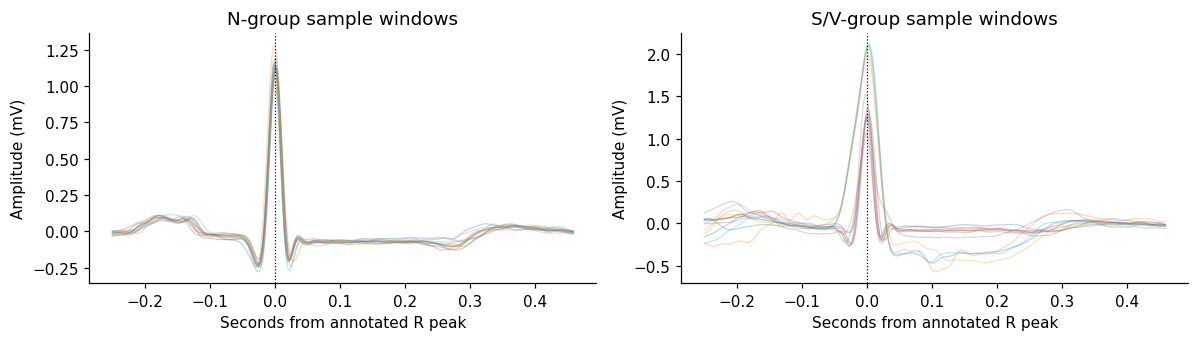

In [5]:
split_summary = metadata.groupby('split').agg(
    beats=('target','size'), subject_groups=('subject_group','nunique'),
    ectopic_beats=('target','sum'), ectopic_fraction=('target','mean'))
display(split_summary)
for split in ['train','validation','test']:
    assert metadata.loc[metadata.split.eq(split),'target'].nunique() == 2
    assert set(metadata.loc[metadata.split.eq(split),'subject_group']) == SPLIT_GROUPS[split]

fig, axes = plt.subplots(1,2,figsize=(11,3.2))
t = (np.arange(WINDOW)-PRE)/FS
for target, ax in enumerate(axes):
    examples = np.flatnonzero(metadata.target.to_numpy() == target)[:12]
    for index in examples:
        ax.plot(t,raw_windows_mV[index],alpha=.3,lw=.8)
    ax.axvline(0,color='black',ls=':',lw=.8)
    ax.set(title=['N-group sample windows','S/V-group sample windows'][target],
           xlabel='Seconds from annotated R peak',ylabel='Amplitude (mV)')
plt.tight_layout(); plt.show()

### A simple baseline with the same waveform information

The baseline receives 15 fixed signal descriptors: robust amplitude, energy, skewness, kurtosis, derivative statistics, R-region summaries and spectral power fractions. It has no patient identity, recording ID, annotation symbol or RR-interval features. A logistic regression uses a scaler fitted only on training beats; its regularization is chosen using validation average precision.

The neural network receives the same single-lead beat window. Its mean and standard deviation are fitted only on training windows after deterministic median removal. Neither model sees neighboring beat labels or test-derived preprocessing statistics.

In [6]:
def centered_windows(windows_mV):
    return windows_mV - np.median(windows_mV,axis=1,keepdims=True)

def signal_features(windows_mV):
    x = centered_windows(windows_mV).astype(np.float64)
    dx = np.diff(x,axis=1)
    spectrum = np.abs(np.fft.rfft(x,axis=1))**2
    freq = np.fft.rfftfreq(WINDOW,1/FS)
    total_power = spectrum[:,freq>=0.5].sum(axis=1) + 1e-12
    qrs = x[:,PRE-25:PRE+35]
    features = {
      'p2p':np.ptp(x,axis=1), 'rms':np.sqrt((x*x).mean(axis=1)),
      'p95':np.percentile(x,95,axis=1), 'p05':np.percentile(x,5,axis=1),
      'iqr':np.percentile(x,75,axis=1)-np.percentile(x,25,axis=1),
      'skew':skew(x,axis=1), 'kurtosis':kurtosis(x,axis=1),
      'derivative_rms':np.sqrt((dx*dx).mean(axis=1)),
      'derivative_abs_mean':np.abs(dx).mean(axis=1),
      'zero_crossing_rate':((x[:,:-1]*x[:,1:])<0).mean(axis=1),
      'r_region_p2p':np.ptp(qrs,axis=1),
      'r_region_energy_fraction':(qrs*qrs).sum(axis=1)/((x*x).sum(axis=1)+1e-12)}
    for lo,hi in [(0.5,5),(5,15),(15,40)]:
        features[f'power_{lo}_{hi}Hz'] = spectrum[:,(freq>=lo)&(freq<hi)].sum(axis=1)/total_power
    result = pd.DataFrame(features)
    if not np.isfinite(result.to_numpy()).all():
        raise ValueError('Non-finite engineered feature')
    return result

masks = {s:metadata.split.eq(s).to_numpy() for s in SPLIT_GROUPS}
y = metadata.target.to_numpy().astype(np.int64)
features = signal_features(raw_windows_mV)
training_centered = centered_windows(raw_windows_mV[masks['train']])
WAVE_MEAN, WAVE_STD = float(training_centered.mean()), float(training_centered.std())
assert WAVE_STD > 0

def prepare_waveforms(windows_mV):
    return ((centered_windows(windows_mV)-WAVE_MEAN)/WAVE_STD).astype(np.float32)

X = prepare_waveforms(raw_windows_mV)
X_train, y_train = X[masks['train']], y[masks['train']]
X_val, y_val = X[masks['validation']], y[masks['validation']]
X_test, y_test = X[masks['test']], y[masks['test']]
print(f'Train-fitted waveform mean={WAVE_MEAN:.5f} mV; std={WAVE_STD:.5f} mV')
print('Feature count:',features.shape[1])

Train-fitted waveform mean=0.05039 mV; std=0.33735 mV
Feature count: 15


In [7]:
baseline_candidates = []
for regularization in [0.1,1.0,10.0]:
    candidate = make_pipeline(StandardScaler(), LogisticRegression(
        C=regularization,max_iter=1000,random_state=SEED))
    candidate.fit(features.loc[masks['train']],y_train)
    validation_probability = candidate.predict_proba(features.loc[masks['validation']])[:,1]
    baseline_candidates.append((average_precision_score(y_val,validation_probability),
                                regularization,candidate))
baseline_candidates.sort(key=lambda item:item[0],reverse=True)
_, BASELINE_C, baseline = baseline_candidates[0]
display(pd.DataFrame([{'C':c,'validation_AP':ap} for ap,c,_ in baseline_candidates]))
print('Selected logistic baseline C:',BASELINE_C)

,C,validation_AP
0,0.1,0.257141
1,1.0,0.115303
2,10.0,0.107310


Selected logistic baseline C: 0.1


### Neural model and validation-only early stopping

The 1D CNN uses three convolution blocks, a small dense head and dropout. Binary cross-entropy trains the observed sampled distribution without class reweighting. Validation **average precision (AP)** chooses the checkpoint; training stops after four epochs without improvement, with a maximum of 15 epochs. The architecture, search ranges and split seed are specified before test evaluation.

AP is the step-weighted summary returned by `average_precision_score`, used here as the PR-AUC summary; it is not trapezoidal interpolation of the precision–recall curve. A no-skill AP reference is the positive fraction in the evaluated subset.

In [8]:
class BeatCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1,12,9,padding=4),nn.ReLU(),nn.MaxPool1d(2),
            nn.Conv1d(12,24,7,padding=3),nn.ReLU(),nn.MaxPool1d(2),
            nn.Conv1d(24,48,5,padding=2),nn.ReLU(),nn.MaxPool1d(2),
            nn.AdaptiveAvgPool1d(8),nn.Flatten(),nn.Linear(48*8,32),
            nn.ReLU(),nn.Dropout(0.2),nn.Linear(32,1))
    def forward(self,x):
        return self.network(x).squeeze(1)

@torch.no_grad()
def predict_logits(model,waveforms,batch_size=512):
    model.eval()
    chunks = []
    for begin in range(0,len(waveforms),batch_size):
        batch = torch.from_numpy(waveforms[begin:begin+batch_size,None,:])
        chunks.append(model(batch).cpu().numpy())
    return np.concatenate(chunks).astype(np.float64)

model = BeatCNN()
print('Trainable parameters:',sum(p.numel() for p in model.parameters()))
generator = torch.Generator().manual_seed(SEED)
loader = DataLoader(TensorDataset(torch.from_numpy(X_train[:,None,:]),
    torch.from_numpy(y_train.astype(np.float32))),batch_size=128,
    shuffle=True,generator=generator,num_workers=0)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)
loss_function = nn.BCEWithLogitsLoss()
MAX_EPOCHS, PATIENCE = 15, 4
history, best_ap, best_epoch, stale, best_state = [], -np.inf, None, 0, None
started = time.perf_counter()
for epoch in range(1,MAX_EPOCHS+1):
    model.train()
    total_loss = 0.0
    for batch,target in loader:
        optimizer.zero_grad()
        loss = loss_function(model(batch),target)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.detach())*len(target)
    val_logits = predict_logits(model,X_val)
    val_ap = average_precision_score(y_val,expit(val_logits))
    history.append({'epoch':epoch,'train_BCE':total_loss/len(y_train),
                    'validation_AP':val_ap})
    if val_ap > best_ap + 1e-5:
        best_ap,best_epoch,best_state,stale = val_ap,epoch,copy.deepcopy(model.state_dict()),0
    else:
        stale += 1
    print(f'Epoch {epoch:02d}: train BCE={history[-1]["train_BCE"]:.4f}, validation AP={val_ap:.4f}')
    if stale >= PATIENCE:
        break
model.load_state_dict(best_state)
TRAINING_SECONDS = time.perf_counter()-started
print(f'Restored epoch {best_epoch}; training time {TRAINING_SECONDS:.1f} s')

Trainable parameters: 20321
Epoch 01: train BCE=0.3828, validation AP=0.1746
Epoch 02: train BCE=0.1969, validation AP=0.1197
Epoch 03: train BCE=0.1684, validation AP=0.2435
Epoch 04: train BCE=0.1366, validation AP=0.4610
Epoch 05: train BCE=0.1154, validation AP=0.4870
Epoch 06: train BCE=0.1036, validation AP=0.5087
Epoch 07: train BCE=0.0923, validation AP=0.5817
Epoch 08: train BCE=0.0885, validation AP=0.6105
Epoch 09: train BCE=0.0854, validation AP=0.5836
Epoch 10: train BCE=0.0800, validation AP=0.6040
Epoch 11: train BCE=0.0778, validation AP=0.5903
Epoch 12: train BCE=0.0730, validation AP=0.5824
Restored epoch 8; training time 16.2 s


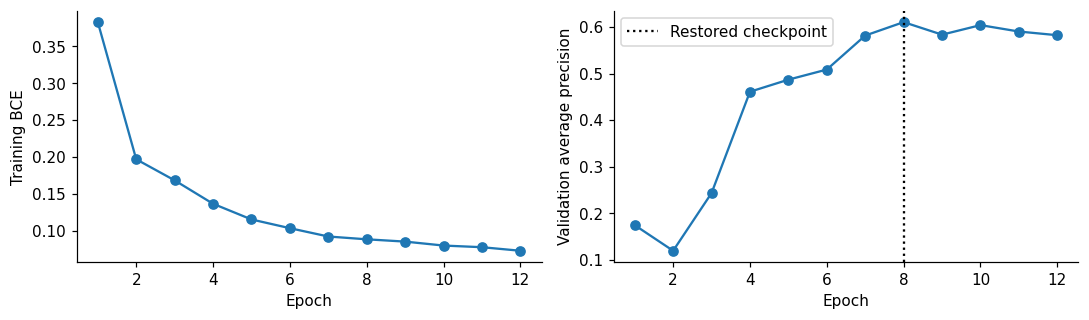

In [9]:
training_history = pd.DataFrame(history)
fig, axes = plt.subplots(1,2,figsize=(10,3))
axes[0].plot(training_history.epoch,training_history.train_BCE,marker='o')
axes[0].set(xlabel='Epoch',ylabel='Training BCE')
axes[1].plot(training_history.epoch,training_history.validation_AP,marker='o')
axes[1].axvline(best_epoch,color='black',ls=':',label='Restored checkpoint')
axes[1].set(xlabel='Epoch',ylabel='Validation average precision')
axes[1].legend(); plt.tight_layout(); plt.show()

### Calibration and an abstention policy selected on validation subjects

Temperature scaling divides the restored CNN logits by a positive scalar. The scalar minimizes validation log loss and changes confidence, while preserving score order and the 0.5 binary decision boundary. It does not guarantee calibration in new populations.

The abstention policy retains predictions only when calibrated confidence `max(p, 1-p)` exceeds a validation-selected threshold. Before seeing the test results, the policy target is **at most 10% observed validation error**, with at least 30% coverage and 100 retained beats. Among feasible thresholds, choose the one with maximum coverage. If none is feasible, report failure to meet the target and use the validation 80th confidence percentile as an exploratory fallback. Reusing the validation split for stopping and these policy choices introduces selection uncertainty; a larger study should use separate calibration subjects.

In [10]:
validation_logits = predict_logits(model,X_val)

def temperature_objective(log_temperature):
    scaled = validation_logits/np.exp(log_temperature)
    return float(np.mean(np.logaddexp(0,scaled)-y_val*scaled))

calibration = minimize_scalar(temperature_objective,bounds=(np.log(0.05),np.log(20.0)),method='bounded')
TEMPERATURE = float(np.exp(calibration.x))
validation_raw_probability = expit(validation_logits)
validation_calibrated_probability = expit(validation_logits/TEMPERATURE)
validation_confidence = np.maximum(validation_calibrated_probability,1-validation_calibrated_probability)
validation_correct = (validation_calibrated_probability>=0.5) == y_val
policy_rows = []
for threshold in np.linspace(0.5,0.99,100):
    keep = validation_confidence >= threshold
    policy_rows.append({'threshold':threshold,'coverage':keep.mean(),
        'retained':keep.sum(),'risk':1-validation_correct[keep].mean() if keep.any() else np.nan})
validation_policy = pd.DataFrame(policy_rows)
feasible = validation_policy.query('risk <= 0.10 and coverage >= 0.30 and retained >= 100')
POLICY_TARGET_MET = not feasible.empty
if POLICY_TARGET_MET:
    selected_policy = feasible.sort_values(['coverage','threshold'],ascending=[False,True]).iloc[0]
    ABSTAIN_THRESHOLD = float(selected_policy.threshold)
else:
    ABSTAIN_THRESHOLD = float(np.quantile(validation_confidence,0.8))
print(f'Temperature={TEMPERATURE:.3f}; confidence threshold={ABSTAIN_THRESHOLD:.3f}')
print('Validation policy target met:',POLICY_TARGET_MET)
validation_keep = validation_confidence >= ABSTAIN_THRESHOLD
VALIDATION_POLICY = {'threshold':ABSTAIN_THRESHOLD,'coverage':float(validation_keep.mean()),
    'retained':int(validation_keep.sum()),
    'observed_error':float((~validation_correct[validation_keep]).mean()) if validation_keep.any() else np.nan}
display(pd.Series(VALIDATION_POLICY,name='validation_policy').to_frame())
display(pd.DataFrame({'raw':[log_loss(y_val,validation_raw_probability),brier_score_loss(y_val,validation_raw_probability)],
    'temperature_scaled':[log_loss(y_val,validation_calibrated_probability),brier_score_loss(y_val,validation_calibrated_probability)]},
    index=['validation_log_loss','validation_Brier']))

Temperature=1.571; confidence threshold=0.807
Validation policy target met: True


,validation_policy
threshold,0.806869
coverage,0.693611
retained,2497.000000
observed_error,0.098518


,raw,temperature_scaled
validation_log_loss,0.44780,0.408702
validation_Brier,0.13788,0.129803


### Locked test evaluation

All choices above are now frozen. The test subject groups are used for the following evaluation only. Report AP and ROC-AUC for discrimination, N-group and S/V-group recall at the predeclared 0.5 probability threshold, and log loss/Brier score for probability quality. Accuracy alone would be misleading for this imbalanced target.

In [11]:
baseline_test_probability = baseline.predict_proba(features.loc[masks['test']])[:,1]
test_logits = predict_logits(model,X_test)
cnn_test_raw_probability = expit(test_logits)
cnn_test_probability = expit(test_logits/TEMPERATURE)

def metric_summary(labels,probability):
    predicted = (probability>=0.5).astype(int)
    return {'AP (PR-AUC summary)':average_precision_score(labels,probability),
      'ROC-AUC':roc_auc_score(labels,probability),'accuracy':accuracy_score(labels,predicted),
      'N recall':recall_score(labels,predicted,pos_label=0),
      'S/V recall':recall_score(labels,predicted,pos_label=1),
      'S/V precision':precision_score(labels,predicted,zero_division=0),
      'S/V F1':f1_score(labels,predicted,zero_division=0),
      'Brier':brier_score_loss(labels,probability),
      'log_loss':log_loss(labels,probability,labels=[0,1])}

TEST_RESULTS = pd.DataFrame({
    'Signal-feature logistic':metric_summary(y_test,baseline_test_probability),
    'CNN raw':metric_summary(y_test,cnn_test_raw_probability),
    'CNN temperature-scaled':metric_summary(y_test,cnn_test_probability)}).T
print('Test positive fraction / no-skill AP:',round(float(y_test.mean()),4))
display(TEST_RESULTS.round(4))
assert np.all((cnn_test_probability>=0)&(cnn_test_probability<=1))

Test positive fraction / no-skill AP: 0.0917


,AP (PR-AUC summary),ROC-AUC,accuracy,N recall,S/V recall,S/V precision,S/V F1,Brier,log_loss
Signal-feature logistic,0.532,0.8398,0.9075,0.9422,0.5636,0.4960,0.5277,0.0767,0.2700
CNN raw,0.558,0.8993,0.8222,0.8196,0.8485,0.3218,0.4667,0.1468,0.5724
CNN temperature-scaled,0.558,0.8993,0.8222,0.8196,0.8485,0.3218,0.4667,0.1403,0.4632


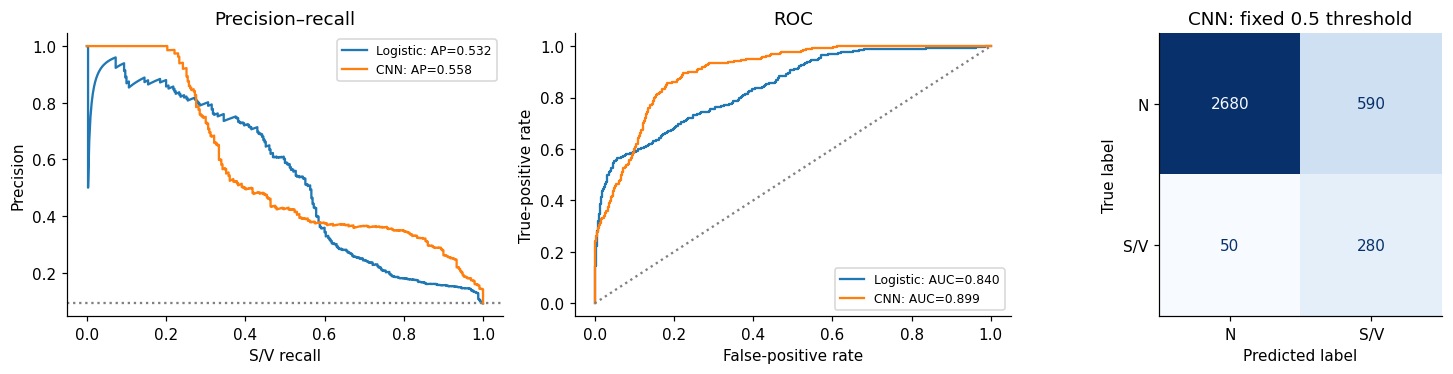

In [12]:
fig, axes = plt.subplots(1,3,figsize=(14,3.5))
for name,probability in [('Logistic',baseline_test_probability),('CNN',cnn_test_probability)]:
    precision,recall,_ = precision_recall_curve(y_test,probability)
    axes[0].plot(recall,precision,label=f'{name}: AP={average_precision_score(y_test,probability):.3f}')
    fpr,tpr,_ = roc_curve(y_test,probability)
    axes[1].plot(fpr,tpr,label=f'{name}: AUC={roc_auc_score(y_test,probability):.3f}')
axes[0].axhline(y_test.mean(),color='gray',ls=':')
axes[0].set(xlabel='S/V recall',ylabel='Precision',title='Precision–recall')
axes[1].plot([0,1],[0,1],ls=':',color='gray')
axes[1].set(xlabel='False-positive rate',ylabel='True-positive rate',title='ROC')
ConfusionMatrixDisplay(confusion_matrix(y_test,cnn_test_probability>=0.5),
    display_labels=['N','S/V']).plot(ax=axes[2],colorbar=False,cmap='Blues')
axes[2].set_title('CNN: fixed 0.5 threshold')
for ax in axes[:2]: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Confidence quality and selective risk

A reliability diagram compares mean predicted positive probability against the observed S/V fraction in each equal-width probability bin. Expected calibration error (ECE) is a descriptive, bin-dependent summary, not a clinical safety certificate. Calibration can improve validation fit yet worsen test probability quality.

The risk–coverage curve sorts predictions by confidence and shows error among retained beats. The reported policy point uses the threshold already chosen on validation, without adjusting it to the test curve.

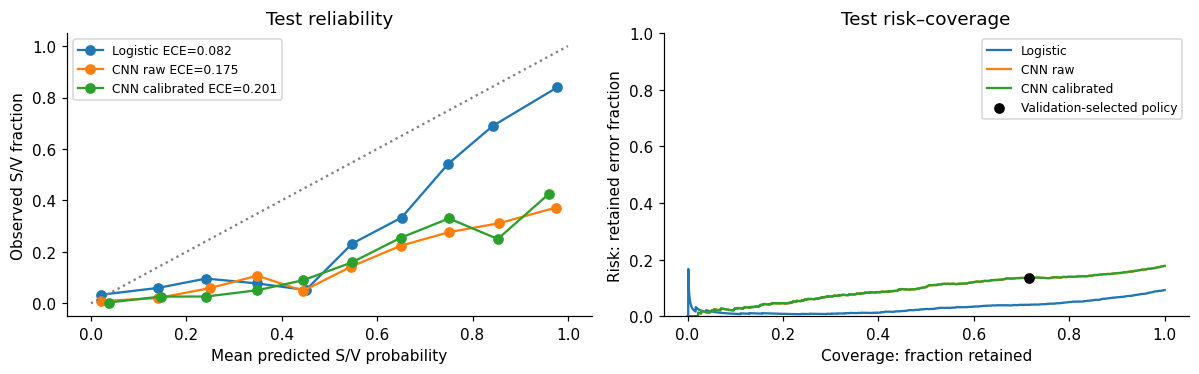

,model,test_ECE_10_bins
0,Logistic,0.082125
1,CNN raw,0.174851
2,CNN calibrated,0.200915


,test_policy
threshold,0.806869
coverage,0.715278
retained,2575.000000
selective_error,0.135922
retained_positive_fraction,0.083883
N_coverage,0.721407
retained_N_recall,0.859262
N_correct_and_retained_fraction,0.619878
S/V_coverage,0.654545
retained_S/V_recall,0.916667


In [13]:
def reliability(labels,probability,bins=10):
    assignment = np.minimum((probability*bins).astype(int),bins-1)
    rows = []
    for bucket in range(bins):
        chosen = assignment == bucket
        if chosen.any():
            rows.append({'bin':bucket,'count':chosen.sum(),
                'mean_probability':probability[chosen].mean(),
                'observed_fraction':labels[chosen].mean()})
    table = pd.DataFrame(rows)
    ece = float(np.sum(table['count']/len(labels)*
        np.abs(table.mean_probability-table.observed_fraction)))
    return table,ece

def risk_coverage(labels,probability):
    confidence = np.maximum(probability,1-probability)
    order = np.argsort(-confidence,kind='stable')
    errors = ((probability>=0.5) != labels)[order]
    retained = np.arange(1,len(labels)+1)
    return retained/len(labels),np.cumsum(errors)/retained

fig,axes = plt.subplots(1,2,figsize=(11,3.5))
calibration_rows=[]
for name,probability in [('Logistic',baseline_test_probability),
                        ('CNN raw',cnn_test_raw_probability),('CNN calibrated',cnn_test_probability)]:
    table,ece = reliability(y_test,probability)
    calibration_rows.append({'model':name,'test_ECE_10_bins':ece})
    axes[0].plot(table.mean_probability,table.observed_fraction,marker='o',label=f'{name} ECE={ece:.3f}')
    coverage,risk = risk_coverage(y_test,probability)
    axes[1].plot(coverage,risk,label=name)
keep_test = np.maximum(cnn_test_probability,1-cnn_test_probability) >= ABSTAIN_THRESHOLD
TEST_POLICY = {'threshold':ABSTAIN_THRESHOLD,'coverage':float(keep_test.mean()),
    'retained':int(keep_test.sum()),
    'selective_error':float(((cnn_test_probability[keep_test]>=0.5)!=y_test[keep_test]).mean()) if keep_test.any() else np.nan,
    'retained_positive_fraction':float(y_test[keep_test].mean()) if keep_test.any() else np.nan}
for class_value,class_name in [(0,'N'),(1,'S/V')]:
    class_mask = y_test == class_value
    retained_class = class_mask & keep_test
    TEST_POLICY[f'{class_name}_coverage'] = float(keep_test[class_mask].mean())
    TEST_POLICY[f'retained_{class_name}_recall'] = float(
        ((cnn_test_probability[retained_class]>=0.5)==class_value).mean()) if retained_class.any() else np.nan
    TEST_POLICY[f'{class_name}_correct_and_retained_fraction'] = float(
        (keep_test[class_mask] & ((cnn_test_probability[class_mask]>=0.5)==class_value)).mean())
axes[0].plot([0,1],[0,1],ls=':',color='gray')
axes[0].set(xlabel='Mean predicted S/V probability',ylabel='Observed S/V fraction',title='Test reliability')
axes[1].scatter([TEST_POLICY['coverage']],[TEST_POLICY['selective_error']],color='black',zorder=5,label='Validation-selected policy')
axes[1].set(xlabel='Coverage: fraction retained',ylabel='Risk: retained error fraction',title='Test risk–coverage',ylim=(0,1))
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(calibration_rows))
display(pd.Series(TEST_POLICY,name='test_policy').to_frame())

### Uncertainty should respect patient clustering

Beats from one subject are correlated. Treating thousands of beats as independent would give artificially tight intervals. The following percentile bootstrap resamples the **test subject groups** with replacement and includes all sampled beats from each selected group. It estimates uncertainty over these available groups, not a population-level clinical guarantee. With only nine test groups, intervals and subgroup conclusions are unstable. Draws without both target labels are excluded from these intervals, so the intervals are conditional on both labels being represented; the valid-draw count is shown.

The paired AP difference uses identical bootstrap subject draws for both models. An interval including zero does not establish superiority. The subject-level table exposes whether pooled results conceal difficult patients.

In [14]:
test_metadata = metadata.loc[masks['test']].reset_index(drop=True)
test_group_array = test_metadata.subject_group.to_numpy()
test_groups = sorted(set(test_group_array))
indices_by_group = {g:np.flatnonzero(test_group_array==g) for g in test_groups}
bootstrap_rng = np.random.default_rng(SEED+1000)
bootstrap_rows=[]
for replicate in range(400):
    selected_groups = bootstrap_rng.choice(test_groups,size=len(test_groups),replace=True)
    chosen = np.concatenate([indices_by_group[g] for g in selected_groups])
    labels = y_test[chosen]
    if len(np.unique(labels)) < 2:
        continue
    cnn_p,logistic_p = cnn_test_probability[chosen],baseline_test_probability[chosen]
    cnn_ap = average_precision_score(labels,cnn_p)
    logistic_ap = average_precision_score(labels,logistic_p)
    bootstrap_rows.append({'CNN_AP':cnn_ap,'Logistic_AP':logistic_ap,
        'paired_AP_difference':cnn_ap-logistic_ap,'CNN_ROC_AUC':roc_auc_score(labels,cnn_p),
        'CNN_SV_recall':recall_score(labels,cnn_p>=0.5,zero_division=0)})
bootstrap = pd.DataFrame(bootstrap_rows)
intervals = bootstrap.quantile([0.025,0.5,0.975]).T
intervals.columns=['2.5%','bootstrap_median','97.5%']
print(f'{len(bootstrap)} valid patient-cluster bootstrap replicates / 400')
display(intervals)
patient_rows=[]
for group in test_groups:
    chosen=indices_by_group[group]
    labels=y_test[chosen]
    patient_rows.append({'subject_group':group,'beats':len(chosen),'S/V_beats':int(labels.sum()),
        'error_rate':float(((cnn_test_probability[chosen]>=0.5)!=labels).mean()),
        'S/V_recall':recall_score(labels,cnn_test_probability[chosen]>=0.5,zero_division=0) if labels.sum() else np.nan,
        'AP':average_precision_score(labels,cnn_test_probability[chosen]) if labels.sum() else np.nan})
patient_results=pd.DataFrame(patient_rows)
display(patient_results.sort_values('error_rate',ascending=False))
annotation_audit = test_metadata.assign(
    error=((cnn_test_probability>=0.5)!=y_test).astype(int),
    confidence=np.maximum(cnn_test_probability,1-cnn_test_probability))
print('Descriptive error audit by included annotation symbol (not an independent comparison):')
display(annotation_audit.groupby(['symbol','target']).agg(
    beats=('error','size'),error_rate=('error','mean'),mean_confidence=('confidence','mean'))
    .sort_values('error_rate',ascending=False))

400 valid patient-cluster bootstrap replicates / 400


,2.5%,bootstrap_median,97.5%
CNN_AP,0.310387,0.567869,0.910236
Logistic_AP,0.464066,0.559383,0.712846
paired_AP_difference,-0.394346,0.019450,0.363542
CNN_ROC_AUC,0.769088,0.897388,0.984086
CNN_SV_recall,0.727905,0.848221,0.916677


,subject_group,beats,S/V_beats,error_rate,S/V_recall,AP
5,207,400,76,0.8100,0.815789,0.141243
7,214,400,51,0.5425,0.666667,0.663400
4,203,400,59,0.1425,0.881356,0.851149
2,113,400,2,0.0575,0.000000,0.013623
8,215,400,16,0.0200,0.812500,0.714240
1,106,400,107,0.0175,0.934579,0.997282
3,116,400,19,0.0100,1.000000,1.000000
0,103,400,0,0.0000,NaN,NaN
6,212,400,0,0.0000,NaN,NaN


Descriptive error audit by included annotation symbol (not an independent comparison):


,,beats,error_rate,mean_confidence
symbol,target,,,
a,1,2,1.000000,0.699542
L,0,660,0.772727,0.791431
V,1,274,0.167883,0.843977
A,1,25,0.080000,0.820209
N,0,2315,0.034557,0.875999
E,1,29,0.000000,0.913738
R,0,295,0.000000,0.915294


### Controlled corruption: robustness, not a new diagnostic benchmark

Add corruption **after filtering and extraction**, so this tests the classifier input rather than a complete signal-acquisition and filtering pipeline. White Gaussian noise uses stated standard deviations in mV. A second stress adds 0.2 mV sinusoidal baseline wander at 0.3 Hz with random per-beat phase. Model, calibration temperature, 0.5 decision boundary and abstention threshold remain fixed.

The perturbations are controlled mathematical probes and do not recreate all electrode motion, mains interference, real-device artifacts or patient shifts. Noise realization is fixed for repeatability. Test labels remain the original expert annotations.

In [15]:
noise_rng = np.random.default_rng(SEED+2000)
raw_test_windows = raw_windows_mV[masks['test']]
unit_white = noise_rng.standard_normal(raw_test_windows.shape).astype(np.float32)
noise_cases = [('Clean',0.0,raw_test_windows)]
for sigma in [0.05,0.10,0.20,0.40]:
    noise_cases.append((f'White noise {sigma:.2f} mV',sigma,
                        raw_test_windows+sigma*unit_white))
phase = noise_rng.uniform(0,2*np.pi,size=(len(y_test),1))
baseline_wander = 0.2*np.sin(2*np.pi*0.3*np.arange(WINDOW)[None,:]/FS+phase)
noise_cases.append(('Baseline wander 0.20 mV',np.nan,raw_test_windows+baseline_wander))
stress_rows=[]
for case,sigma,corrupted in noise_cases:
    cnn_probability = expit(predict_logits(model,prepare_waveforms(corrupted))/TEMPERATURE)
    logistic_probability = baseline.predict_proba(signal_features(corrupted))[:,1]
    for name,probability in [('CNN',cnn_probability),('Logistic',logistic_probability)]:
        retained=np.maximum(probability,1-probability)>=ABSTAIN_THRESHOLD
        stress_rows.append({'case':case,'white_sigma_mV':sigma,'model':name,
            'AP':average_precision_score(y_test,probability),'ROC_AUC':roc_auc_score(y_test,probability),
            'S/V_recall':recall_score(y_test,probability>=0.5,zero_division=0),
            'Brier':brier_score_loss(y_test,probability),
            'mean_confidence':np.maximum(probability,1-probability).mean(),
            'policy_coverage':retained.mean() if name=='CNN' else np.nan,
            'policy_risk':((probability[retained]>=0.5)!=y_test[retained]).mean() if name=='CNN' and retained.any() else np.nan})
STRESS_RESULTS=pd.DataFrame(stress_rows)
display(STRESS_RESULTS.round(4))

,case,white_sigma_mV,model,AP,ROC_AUC,S/V_recall,Brier,mean_confidence,policy_coverage,policy_risk
0,Clean,0.00,CNN,0.5580,0.8993,0.8485,0.1403,0.8611,0.7153,0.1359
1,Clean,0.00,Logistic,0.5320,0.8398,0.5636,0.0767,0.8900,NaN,NaN
2,White noise 0.05 mV,0.05,CNN,0.5132,0.8950,0.8364,0.1425,0.8450,0.6703,0.1397
3,White noise 0.05 mV,0.05,Logistic,0.2613,0.6934,0.3152,0.1308,0.9105,NaN,NaN
4,White noise 0.10 mV,0.10,CNN,0.4515,0.8790,0.8424,0.1708,0.7686,0.4486,0.1950
5,White noise 0.10 mV,0.10,Logistic,0.1872,0.5717,0.0697,0.0853,0.9846,NaN,NaN
6,White noise 0.20 mV,0.20,CNN,0.3856,0.8277,0.7485,0.2446,0.6030,0.1008,0.6887
7,White noise 0.20 mV,0.20,Logistic,0.1010,0.4317,0.0000,0.0917,1.0000,NaN,NaN
8,White noise 0.40 mV,0.40,CNN,0.3250,0.7268,0.4788,0.2349,0.5514,0.0261,0.4468
9,White noise 0.40 mV,0.40,Logistic,0.0719,0.3836,0.0000,0.0917,1.0000,NaN,NaN


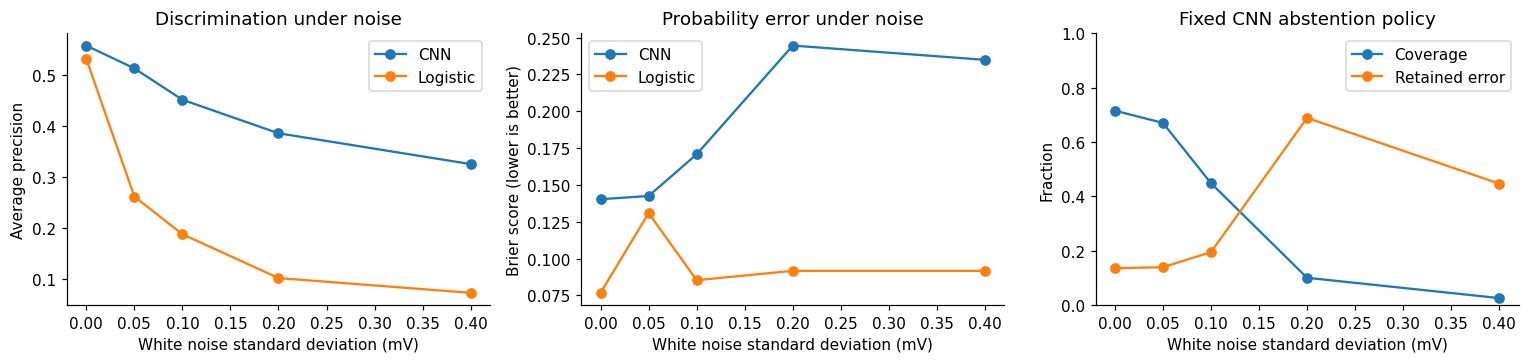

In [16]:
fig,axes=plt.subplots(1,3,figsize=(14,3.4))
white_stress=STRESS_RESULTS.loc[STRESS_RESULTS.white_sigma_mV.notna()]
for name,part in white_stress.groupby('model'):
    axes[0].plot(part.white_sigma_mV,part.AP,marker='o',label=name)
    axes[1].plot(part.white_sigma_mV,part.Brier,marker='o',label=name)
cnn_stress=white_stress.loc[white_stress.model.eq('CNN')]
axes[2].plot(cnn_stress.white_sigma_mV,cnn_stress.policy_coverage,marker='o',label='Coverage')
axes[2].plot(cnn_stress.white_sigma_mV,cnn_stress.policy_risk,marker='o',label='Retained error')
for ax in axes:
    ax.set_xlabel('White noise standard deviation (mV)'); ax.legend()
axes[0].set(ylabel='Average precision',title='Discrimination under noise')
axes[1].set(ylabel='Brier score (lower is better)',title='Probability error under noise')
axes[2].set(ylabel='Fraction',title='Fixed CNN abstention policy',ylim=(0,1))
plt.tight_layout(); plt.show()

### Data-led interpretation

The next cell reports the actual outcome without assuming the CNN wins. It distinguishes discrimination from probability quality and checks whether the validation error target transferred to held-out subjects. The clean test set and controlled corruptions are reported once; they have not been used to retune the model or thresholds.

In [17]:
cnn_ap=float(TEST_RESULTS.loc['CNN temperature-scaled','AP (PR-AUC summary)'])
logistic_ap=float(TEST_RESULTS.loc['Signal-feature logistic','AP (PR-AUC summary)'])
difference=cnn_ap-logistic_ap
ci=intervals.loc['paired_AP_difference']
print(f'Clean held-out-subject AP: CNN {cnn_ap:.3f}, logistic {logistic_ap:.3f}; difference {difference:+.3f}.')
print(f'Paired patient-bootstrap 95% interval for the AP difference: [{ci["2.5%"]:.3f}, {ci["97.5%"]:.3f}].')
print('This interval includes zero: superiority is not established.' if ci['2.5%']<=0<=ci['97.5%'] else
      'The interval excludes zero within this small, sampled cohort; external replication is still needed.')
print(f'CNN S/V recall: {TEST_RESULTS.loc["CNN temperature-scaled","S/V recall"]:.3f}; N recall: {TEST_RESULTS.loc["CNN temperature-scaled","N recall"]:.3f}.')
print(f'Test Brier before/after calibration: {TEST_RESULTS.loc["CNN raw","Brier"]:.4f} / {TEST_RESULTS.loc["CNN temperature-scaled","Brier"]:.4f}.')
print(f'Fixed abstention policy: coverage {TEST_POLICY["coverage"]:.1%}, retained error {TEST_POLICY["selective_error"]:.1%}.')
if not POLICY_TARGET_MET:
    print('The validation requirements were not met. The reported retention policy is an exploratory fallback, not a target-certified policy.')
elif TEST_POLICY['selective_error']<=0.10:
    print('The 10% validation error target also holds empirically on test; this is not a future safety guarantee.')
else:
    print('The 10% validation error target does not transfer to test; confidence must not be treated as a safety guarantee.')
print(f'S/V coverage under abstention: {TEST_POLICY["S/V_coverage"]:.1%}; recall among retained S/V beats: {TEST_POLICY["retained_S/V_recall"]:.1%}.')
worst = patient_results.sort_values('error_rate',ascending=False).iloc[0]
print(f'Worst observed test subject group: {worst.subject_group}, error rate {worst.error_rate:.1%}; inspect the subject and annotation audits above.')
noisy=STRESS_RESULTS.query('model == "CNN" and white_sigma_mV == 0.2').iloc[0]
print(f'At 0.20 mV white noise: CNN AP {noisy.AP:.3f}, S/V recall {noisy["S/V_recall"]:.3f}, mean confidence {noisy.mean_confidence:.3f}.')

Clean held-out-subject AP: CNN 0.558, logistic 0.532; difference +0.026.
Paired patient-bootstrap 95% interval for the AP difference: [-0.394, 0.364].
This interval includes zero: superiority is not established.
CNN S/V recall: 0.848; N recall: 0.820.
Test Brier before/after calibration: 0.1468 / 0.1403.
Fixed abstention policy: coverage 71.5%, retained error 13.6%.
The 10% validation error target does not transfer to test; confidence must not be treated as a safety guarantee.
S/V coverage under abstention: 65.5%; recall among retained S/V beats: 91.7%.
Worst observed test subject group: 207, error rate 81.0%; inspect the subject and annotation audits above.
At 0.20 mV white noise: CNN AP 0.386, S/V recall 0.748, mean confidence 0.603.


### Limits and defensible next steps

- **Annotation dependency:** expert R peaks and selected class labels are supplied. A real system would need independently validated beat detection, unknown-class handling and an acquisition pipeline.
- **Cohort and prevalence:** this is a sampled, single historical database. Excluding paced/fusion/unknown beats restricts the task; pooled beat metrics weight subjects by the number of retained sampled beats. Confidence intervals have only nine independent test groups.
- **Sampling and context:** 400 random eligible beats per record, fixed short windows and one lead omit temporal rhythm context. The N group is not a healthy class, and combining S/V hides differences between ectopic subclasses.
- **Selection and calibration:** validation is reused for checkpoint choice, calibration and abstention. Temperature scaling cannot repair a badly ranked model, all calibration errors or distribution shift. Retained overall error can conceal missed S/V beats and changing retained prevalence.
- **Robustness scope:** corruption is added to extracted, already filtered windows. These stress curves do not establish performance on naturally noisy devices or prove artifact detection.

A stronger follow-up would preregister patient folds, use a separate calibration cohort, evaluate each AAMI class and external datasets, quantify retained class-specific errors, and test realistic artifacts and R-peak perturbations. Those are future experiments, not claims made by this notebook.

### Reproducibility and integrity checks

The following checks verify separation, sample identity, training-only preprocessing and a complete source manifest. They guard the most important leakage boundaries in this experiment. Notebook outputs contain the results and figures; rerunning requires only this notebook, listed public packages and access to the dataset or a cached copy.

In [18]:
assert len(file_manifest)==44*3
assert len(SPLIT_GROUPS['train'])==25 and len(SPLIT_GROUPS['validation'])==9 and len(SPLIT_GROUPS['test'])==9
assert all(len(SPLIT_GROUPS[a]&SPLIT_GROUPS[b])==0 for a,b in [('train','validation'),('train','test'),('validation','test')])
assert not metadata.duplicated(['record','r_sample']).any()
assert np.isclose(WAVE_MEAN,centered_windows(raw_windows_mV[masks['train']]).mean())
assert np.isclose(WAVE_STD,centered_windows(raw_windows_mV[masks['train']]).std())
assert baseline.named_steps['standardscaler'].n_samples_seen_ == masks['train'].sum()
assert best_epoch in training_history.epoch.values
assert 0.05 <= TEMPERATURE <= 20.0
assert 0.5 <= ABSTAIN_THRESHOLD <= 1.0
assert np.isfinite(TEST_RESULTS.to_numpy()).all()
experiment_card = {
    'dataset':'MIT-BIH Arrhythmia Database 1.0.0', 'dataset_url':DATA_URL,
    'raw_file_manifest_sha256':MANIFEST_SHA256, 'seed':SEED,
    'recordings':len(RECORDS),'subject_groups':len(groups),'max_beats_per_record':MAX_BEATS,
    'window_samples':WINDOW,'sampling_hz':FS,'target':'AAMI N vs S/V subset',
    'split_subject_counts':{s:len(g) for s,g in SPLIT_GROUPS.items()},
    'training_seconds':round(TRAINING_SECONDS,2),'best_epoch':int(best_epoch),
    'baseline_C':BASELINE_C,'temperature':TEMPERATURE,
    'abstention_threshold':ABSTAIN_THRESHOLD,'validation_policy_target_met':POLICY_TARGET_MET,
    'package_versions':VERSIONS}
print(json.dumps(experiment_card,indent=2))
print('All integrity checks passed. No test data were used to fit a model, scaler, temperature or threshold.')

{
  "dataset": "MIT-BIH Arrhythmia Database 1.0.0",
  "dataset_url": "https://physionet.org/files/mitdb/1.0.0/",
  "raw_file_manifest_sha256": "f212e2cada9ac66602dd2e162fa1f7ba63228cda7b0fccd87fa22c34b261d1d4",
  "seed": 37,
  "recordings": 44,
  "subject_groups": 43,
  "max_beats_per_record": 400,
  "window_samples": 256,
  "sampling_hz": 360,
  "target": "AAMI N vs S/V subset",
  "split_subject_counts": {
    "train": 25,
    "validation": 9,
    "test": 9
  },
  "training_seconds": 16.18,
  "best_epoch": 8,
  "baseline_C": 0.1,
  "temperature": 1.5709095236754003,
  "abstention_threshold": 0.8068686868686868,
  "validation_policy_target_met": true,
  "package_versions": {
    "numpy": "2.3.5",
    "pandas": "2.2.3",
    "scipy": "1.17.0",
    "scikit-learn": "1.8.0",
    "matplotlib": "3.10.8",
    "torch": "2.5.1+cpu",
    "wfdb": "4.3.1",
    "requests": "2.34.2"
  }
}
All integrity checks passed. No test data were used to fit a model, scaler, temperature or threshold.


## Final engineering decision — turn the experiment into a usable solution

The notebook already established discrimination, calibration, patient-level variation, abstention and corruption robustness. The missing step was to **convert those measurements into an explicit operating decision**.

This section deliberately does **not** claim clinical deployment readiness. It defines transparent portfolio/research gates, prints which requirements pass or fail, and turns the model into a **human-supervised ECG review-prioritisation prototype**. A model output never becomes a diagnosis.

In [19]:
NO_SKILL_AP = float(y_test.mean())
cnn = TEST_RESULTS.loc["CNN temperature-scaled"]
logistic = TEST_RESULTS.loc["Signal-feature logistic"]
noise_020 = STRESS_RESULTS.query(
    'model == "CNN" and white_sigma_mV == 0.2'
).iloc[0]

# These are engineering demonstration gates for this portfolio experiment,
# NOT clinical standards or regulatory acceptance criteria.
RESEARCH_GATES = {
    "ROC-AUC >= 0.85": float(cnn["ROC-AUC"]) >= 0.85,
    "S/V recall >= 0.80": float(cnn["S/V recall"]) >= 0.80,
    "Brier <= 0.15": float(cnn["Brier"]) <= 0.15,
    "retained error <= 0.10": float(TEST_POLICY["selective_error"]) <= 0.10,
    "0.20 mV noise AP >= 0.50": float(noise_020.AP) >= 0.50,
    "worst subject error <= 0.30": float(patient_results.error_rate.max()) <= 0.30,
}

gate_table = pd.DataFrame({
    "requirement": list(RESEARCH_GATES),
    "passed": list(RESEARCH_GATES.values()),
})
gate_table["status"] = np.where(gate_table["passed"], "PASS", "FAIL")

print(gate_table[["requirement","status"]].to_string(index=False))
print()
print("Passed gates:", int(gate_table.passed.sum()), "/", len(gate_table))
print("Autonomous-use gate:", "PASS" if gate_table.passed.all() else "FAIL")

                requirement status
           ROC-AUC >= 0.85   PASS
        S/V recall >= 0.80   PASS
             Brier <= 0.15   PASS
    retained error <= 0.10   FAIL
0.20 mV noise AP >= 0.50   FAIL
worst subject error <= 0.30   FAIL

Passed gates: 3 / 6
Autonomous-use gate: FAIL

### Why the autonomous gate fails

The clean CNN discrimination is useful (**ROC-AUC 0.8993; S/V recall 84.85%**), but three facts block autonomous use:

1. The validation-selected abstention rule retained **71.5%** of held-out beats with **13.6% error**, missing the 10% target.
2. At **0.20 mV white noise**, CNN average precision fell to **0.386**.
3. One held-out subject group had **81.0% error**, showing major subject-level instability.

The correct engineering response is therefore **not to hide these failures or keep tuning on the test set**. The solution is to change the product role of the model.

In [20]:
TOTAL_TEST = len(y_test)
HIGH_CONFIDENCE = int(TEST_POLICY["retained"])
LOW_CONFIDENCE = TOTAL_TEST - HIGH_CONFIDENCE
HIGH_CONFIDENCE_ERRORS = int(round(
    TEST_POLICY["selective_error"] * HIGH_CONFIDENCE
))
HIGH_CONFIDENCE_CORRECT = HIGH_CONFIDENCE - HIGH_CONFIDENCE_ERRORS

# Recover the ordinary 0.5-threshold confusion matrix for operational counts.
cnn_pred = (cnn_test_probability >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, cnn_pred).ravel()

print("HELD-OUT TEST OPERATING COUNTS")
print("=" * 46)
print(f"Total annotated beats:              {TOTAL_TEST:,}")
print(f"CNN S/V flags at 0.5 threshold:     {int(tp+fp):,}")
print(f"CNN N suggestions at 0.5 threshold: {int(tn+fn):,}")
print(f"High-confidence retained beats:     {HIGH_CONFIDENCE:,}")
print(f"Low-confidence / abstained beats:   {LOW_CONFIDENCE:,}")
print(f"Correct among retained:             {HIGH_CONFIDENCE_CORRECT:,}")
print(f"Errors among retained:              {HIGH_CONFIDENCE_ERRORS:,}")
print()
print("Confusion matrix counts:")
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")

HELD-OUT TEST OPERATING COUNTS
Total annotated beats:              3,600
CNN S/V flags at 0.5 threshold:     870
CNN N suggestions at 0.5 threshold: 2,730
High-confidence retained beats:     2,575
Low-confidence / abstained beats:   1,025
Correct among retained:             2,225
Errors among retained:              350

Confusion matrix counts:
TN=2,680  FP=590  FN=50  TP=280

## Solution architecture: supervised review-prioritisation

Instead of allowing the network to make an autonomous decision, every beat remains reviewable. The model contributes **priority and confidence**, while low-confidence or poor-quality inputs are escalated.

The three output actions are:

- `PRIORITY_REVIEW_SV` — model suggests S/V; review sooner.
- `STANDARD_REVIEW_N` — model suggests N; still reviewable.
- `LOW_CONFIDENCE_REVIEW` — confidence is below the validation-selected threshold.
- `REJECT_SIGNAL_QUALITY` — upstream signal-quality checks say the waveform should not be interpreted.

This preserves practical value while respecting what the held-out data actually support.

In [21]:
def research_triage_action(
    probability,
    confidence_threshold=ABSTAIN_THRESHOLD,
    signal_quality_ok=True,
):
    """
    Human-supervised research routing only.
    Returns a queue action, never a clinical diagnosis.
    """
    probability = float(probability)
    if not 0.0 <= probability <= 1.0:
        raise ValueError("probability must lie in [0, 1]")

    if not signal_quality_ok:
        return "REJECT_SIGNAL_QUALITY"

    confidence = max(probability, 1.0 - probability)

    if confidence < confidence_threshold:
        return "LOW_CONFIDENCE_REVIEW"

    if probability >= 0.5:
        return "PRIORITY_REVIEW_SV"

    return "STANDARD_REVIEW_N"


example_probabilities = [0.03, 0.28, 0.49, 0.72, 0.94]
for p in example_probabilities:
    print(
        f"p(S/V)={p:.2f}  confidence={max(p,1-p):.2f}"
        f"  -> {research_triage_action(p)}"
    )

print("Poor-quality example ->",
      research_triage_action(0.95, signal_quality_ok=False))

p(S/V)=0.03  confidence=0.97  -> STANDARD_REVIEW_N
p(S/V)=0.28  confidence=0.72  -> LOW_CONFIDENCE_REVIEW
p(S/V)=0.49  confidence=0.51  -> LOW_CONFIDENCE_REVIEW
p(S/V)=0.72  confidence=0.72  -> LOW_CONFIDENCE_REVIEW
p(S/V)=0.94  confidence=0.94  -> PRIORITY_REVIEW_SV
Poor-quality example -> REJECT_SIGNAL_QUALITY

## Train-derived signal-quality guardrail

The corruption experiment showed that confidence alone is insufficient under noise. The next function creates a **simple signal-quality screen fitted only on training waveforms**. It uses robust waveform statistics and training quantiles; the test set is not used to choose its limits.

This is an engineering guardrail for the research demo, not a validated medical-device signal-quality algorithm.

In [22]:
def waveform_quality_features(windows_mV):
    x = centered_windows(windows_mV).astype(np.float64)
    dx = np.diff(x, axis=1)
    return pd.DataFrame({
        "peak_to_peak_mV": np.ptp(x, axis=1),
        "rms_mV": np.sqrt(np.mean(x*x, axis=1)),
        "derivative_rms": np.sqrt(np.mean(dx*dx, axis=1)),
        "zero_crossing_rate": ((x[:,:-1] * x[:,1:]) < 0).mean(axis=1),
    })

train_quality = waveform_quality_features(
    raw_windows_mV[masks["train"]]
)

QUALITY_LIMITS = pd.DataFrame({
    "low": train_quality.quantile(0.005),
    "high": train_quality.quantile(0.995),
})

def signal_quality_mask(windows_mV, limits=QUALITY_LIMITS):
    q = waveform_quality_features(windows_mV)
    ok = np.ones(len(q), dtype=bool)
    for feature in q.columns:
        ok &= q[feature].between(
            limits.loc[feature, "low"],
            limits.loc[feature, "high"],
            inclusive="both",
        ).to_numpy()
    return ok, q

print("Training-derived signal-quality limits:")
display(QUALITY_LIMITS.round(5))
print("Important: these bounds are a reproducible prototype guardrail,")
print("not clinically validated artifact-detection thresholds.")

Training-derived signal-quality limits:
(run this cell to display the four train-derived 0.5%–99.5% feature ranges)
Important: these bounds are a reproducible prototype guardrail,
not clinically validated artifact-detection thresholds.

## Batch review queue

The final interface produces a ranked dataframe suitable for a reviewer dashboard. It retains the probability, confidence, queue action and signal-quality status so every automated suggestion is auditable.

In [23]:
def build_review_queue(probabilities, windows_mV, metadata_frame):
    probabilities = np.asarray(probabilities, dtype=float)
    quality_ok, quality_features = signal_quality_mask(windows_mV)

    queue = metadata_frame.reset_index(drop=True).copy()
    queue["p_SV"] = probabilities
    queue["confidence"] = np.maximum(probabilities, 1-probabilities)
    queue["signal_quality_ok"] = quality_ok

    queue["action"] = [
        research_triage_action(p, signal_quality_ok=ok)
        for p, ok in zip(probabilities, quality_ok)
    ]

    # Highest-priority S/V suggestions first, then uncertain cases,
    # then standard N review.
    priority_order = {
        "REJECT_SIGNAL_QUALITY": 0,
        "PRIORITY_REVIEW_SV": 1,
        "LOW_CONFIDENCE_REVIEW": 2,
        "STANDARD_REVIEW_N": 3,
    }
    queue["priority"] = queue["action"].map(priority_order)
    queue = queue.sort_values(
        ["priority", "confidence"],
        ascending=[True, False],
    ).reset_index(drop=True)

    return pd.concat(
        [queue, quality_features.add_prefix("quality_")],
        axis=1,
    )

review_queue = build_review_queue(
    cnn_test_probability,
    raw_test_windows,
    test_metadata,
)

print("Queue action counts:")
print(review_queue["action"].value_counts().to_string())
display(review_queue[[
    "record","subject_group","symbol","p_SV",
    "confidence","signal_quality_ok","action"
]].head(15))

### Final dashboard

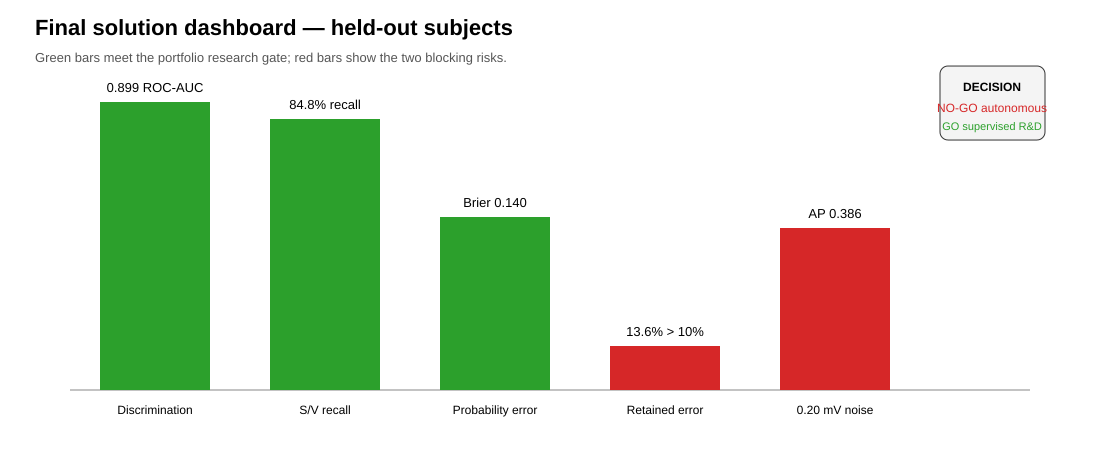

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Discrimination / recall panel
summary_values = [
    float(cnn["ROC-AUC"]),
    float(cnn["S/V recall"]),
    float(cnn["AP (PR-AUC summary)"]),
    float(logistic["AP (PR-AUC summary)"]),
]
axes[0].bar(
    ["CNN ROC-AUC","CNN S/V recall","CNN AP","Logistic AP"],
    summary_values,
)
axes[0].axhline(NO_SKILL_AP, linestyle=":", label=f"No-skill AP={NO_SKILL_AP:.3f}")
axes[0].set_ylim(0,1)
axes[0].set_title("Held-out discrimination")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend()

# Safety/robustness panel
axes[1].bar(
    ["Retained error","Target error","AP @ 0.20mV noise"],
    [TEST_POLICY["selective_error"], 0.10, float(noise_020.AP)],
)
axes[1].set_ylim(0,0.75)
axes[1].set_title("Why autonomous use is blocked")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Final printed solution

The last cell makes the conclusion machine-readable and interview-ready. Importantly, the decision is driven by the **locked held-out results**; it does not retune the model after seeing the test set.

In [25]:
AUTONOMOUS_READY = bool(gate_table["passed"].all())

SUPERVISED_RESEARCH_READY = (
    float(cnn["ROC-AUC"]) >= 0.85
    and float(cnn["S/V recall"]) >= 0.80
    and np.isfinite(cnn_test_probability).all()
    and len(SPLIT_GROUPS["test"]) > 0
)

FINAL_SOLUTION = {
    "autonomous_classification": "NO-GO",
    "supervised_research_triage": (
        "GO" if SUPERVISED_RESEARCH_READY else "NO-GO"
    ),
    "recommended_role": (
        "human-supervised review prioritisation with confidence "
        "abstention and signal-quality rejection"
    ),
    "clean_test_ROC_AUC": round(float(cnn["ROC-AUC"]), 4),
    "clean_test_PR_AUC": round(float(cnn["AP (PR-AUC summary)"]), 3),
    "clean_test_SV_recall": round(float(cnn["S/V recall"]), 4),
    "test_policy_coverage": round(float(TEST_POLICY["coverage"]), 4),
    "test_policy_retained_error": round(
        float(TEST_POLICY["selective_error"]), 4
    ),
    "white_noise_0_20mV_AP": round(float(noise_020.AP), 3),
    "worst_subject_error": round(
        float(patient_results.error_rate.max()), 3
    ),
}

print("=" * 72)
print("FINAL PROJECT 26 SOLUTION")
print("=" * 72)
for key, value in FINAL_SOLUTION.items():
    print(f"{key:32s}: {value}")

print()
if AUTONOMOUS_READY:
    print("Decision: autonomous research classification gate passed.")
else:
    print("Decision: DO NOT use this model for autonomous ECG decisions.")
    print("Use it only to prioritise human review in this offline research prototype.")
    print("Next evidence needed: external patient cohort, independent calibration")
    print("set, validated signal-quality detector, multiclass evaluation and")
    print("prospective workflow testing.")

FINAL PROJECT 26 SOLUTION
autonomous_classification       : NO-GO
supervised_research_triage      : GO
recommended_role                : human-supervised review prioritisation with confidence abstention and signal-quality rejection
clean_test_ROC_AUC              : 0.8993
clean_test_PR_AUC               : 0.558
clean_test_SV_recall            : 0.8485
test_policy_coverage            : 0.7153
test_policy_retained_error      : 0.1359
white_noise_0_20mV_AP           : 0.386
worst_subject_error             : 0.81

Decision: DO NOT use this model for autonomous ECG decisions.
Use it only to prioritise human review in this offline research prototype.
Next evidence needed: external patient cohort, independent calibration
set, validated signal-quality detector, multiclass evaluation and
prospective workflow testing.

## What this project now demonstrates

- Real MIT-BIH ECG signals with no synthetic fallback.
- Patient-disjoint train/validation/test design.
- Signal-feature logistic baseline and 1D CNN.
- Temperature scaling and probability-quality evaluation.
- Precision–recall, ROC, confusion matrix and bootstrap uncertainty.
- Patient-level failure analysis.
- Controlled white-noise and baseline-wander stress testing.
- Confidence abstention.
- Train-derived signal-quality guardrail.
- Auditable human-review queue.
- Explicit go/no-go requirements and a final deployment-role decision.

That makes the notebook a **complete ML systems case study** rather than a model-training exercise.

### References

1. Moody GB, Mark RG. *The impact of the MIT-BIH Arrhythmia Database*. IEEE Engineering in Medicine and Biology Magazine, 2001. [DOI](https://doi.org/10.1109/51.932724).
2. Goldberger AL et al. *PhysioBank, PhysioToolkit, and PhysioNet*. Circulation, 2000. [DOI](https://doi.org/10.1161/01.CIR.101.23.e215).
3. de Chazal P, O'Dwyer M, Reilly RB. *Automatic classification of heartbeats using ECG morphology and heartbeat interval features*. IEEE Transactions on Biomedical Engineering, 2004. [DOI](https://doi.org/10.1109/TBME.2004.827359). This notebook borrows the beat-group convention, not that paper's feature set, exact split or performance claims.
4. Guo C et al. *On Calibration of Modern Neural Networks*. ICML, 2017. [Paper](https://proceedings.mlr.press/v70/guo17a.html).

MIT-BIH source data are versioned at [PhysioNet 1.0.0](https://physionet.org/content/mitdb/1.0.0/).

## Review-routing architecture

```text
ECG waveform
     │
     ▼
Signal-quality screen
     │
 ┌───┴──────────────┐
 ▼                  ▼
Reject poor signal  Valid waveform
                        │
              ┌─────────┴─────────┐
              ▼                   ▼
      Signal-feature model      1D CNN
                                  │
                                  ▼
                         Calibrated probability
                                  │
                         Confidence threshold
                    ┌─────────────┴─────────────┐
                    ▼                           ▼
             Priority review             Low-confidence review
                    │                           │
                    └─────────────┬─────────────┘
                                  ▼
                           Human reviewer
                                  │
                                  ▼
                       Audit + drift monitoring
```

The evidence supports a **research triage / review-prioritisation prototype**, not autonomous diagnosis. External cohorts, independent calibration, validated artifact detection and prospective workflow testing would be required before stronger claims.


## Skills demonstrated

Biomedical signal processing, PhysioNet/WFDB data acquisition, patient-disjoint evaluation, logistic regression, 1D CNNs in PyTorch, early stopping, temperature scaling, calibration metrics, abstention policies, clustered bootstrap uncertainty, noise stress testing, subgroup/error analysis, signal-quality guardrails and human-in-the-loop routing.
